# Import necessary libraries

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import LineString
import utm
from sklearn.preprocessing import StandardScaler

# Remove warning 

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Read Dataset

In [3]:
Data_folder = 'Dataset'

# Read  data
data_files = [os.path.join(Data_folder, file) for file in os.listdir(Data_folder) if file.endswith('.csv')]
df = pd.concat([pd.read_csv(file) for file in data_files], ignore_index=True)

In [4]:
df.shape

(70998, 186)

# List the Features

In [5]:
column_names = df.columns.tolist()
print("Column Names:")
for column_name in column_names:
    print(column_name)

Column Names:
CUSTOM.date [local]
CUSTOM.updateTime [local]
OSD.flyTime
OSD.flyTime [s]
OSD.latitude
OSD.longitude
OSD.height [ft]
OSD.heightMax [ft]
OSD.vpsHeight [ft]
OSD.altitude [ft]
OSD.mileage [ft]
OSD.hSpeed [MPH]
OSD.hSpeedMax [MPH]
OSD.xSpeed [MPH]
OSD.xSpeedMax [MPH]
OSD.ySpeed [MPH]
OSD.ySpeedMax [MPH]
OSD.zSpeed [MPH]
OSD.zSpeedMax [MPH]
OSD.pitch
OSD.roll
OSD.yaw
OSD.yaw [360]
OSD.flycState
OSD.flycCommand
OSD.flightAction
OSD.gpsNum
OSD.gpsLevel
OSD.isGPSUsed
OSD.nonGPSCause
OSD.droneType
OSD.isSwaveWork
OSD.waveError
OSD.goHomeStatus
OSD.batteryType
OSD.ctrlDevice
OSD.isOnGround
OSD.isMotorOn
OSD.isMotorBlocked
OSD.motorStartFailedCause
OSD.motorFailReason
OSD.isImuPreheated
OSD.imuInitFailReason
OSD.isAcceletorOverRange
OSD.isBarometerDeadInAir
OSD.isCompassError
OSD.isGoHomeHeightModified
OSD.canIOCWork
OSD.isNotEnoughForce
OSD.isOutOfLimit
OSD.isPropellerCatapult
OSD.isVibrating
OSD.isVisionUsed
OSD.voltageWarning
GIMBAL.mode
GIMBAL.pitch
GIMBAL.roll
GIMBAL.yaw
GIMBAL

# Feature Selection

In [6]:
features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

In [7]:
df=df[features]
df

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0m 0.0s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,113.9
1,0m 0.1s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
2,0m 0.2s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
3,0m 0.3s,1024,1024,1024,1024,80.353166,7.498430,0.0,5.7,2.5,114.0
4,0m 0.4s,1024,1024,1024,1024,80.353166,7.498429,0.0,5.7,2.5,114.1
...,...,...,...,...,...,...,...,...,...,...,...
70993,12m 15.1s,1024,1024,364,1024,79.914412,6.974626,2.2,2.2,-2.0,-168.8
70994,12m 15.2s,1024,1024,364,1024,79.914412,6.974626,2.2,2.5,-2.5,-169.0
70995,12m 15.3s,1024,1024,364,1024,79.914412,6.974626,2.2,2.5,-1.7,-169.2
70996,12m 15.4s,1024,1024,364,1024,79.914412,6.974626,2.2,2.7,-1.4,-169.5


# Convert time string to seconds function

In [8]:
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

# Preprocess 'OSD.flyTime' column
df['OSD.flyTime'] = df['OSD.flyTime'].apply(time_to_seconds)


# Data Analysis

# Range of each features

Range of values for each feature:
                        min          max
OSD.flyTime        0.000000  1176.300000
RC.aileron       364.000000  1684.000000
RC.elevator      364.000000  1684.000000
RC.throttle      364.000000  1684.000000
RC.rudder        364.000000  1684.000000
OSD.longitude     79.913877    80.353385
OSD.latitude       6.972471     7.498461
OSD.height [ft]   -6.800000   115.800000
OSD.pitch        -23.600000    27.400000
OSD.roll         -19.600000    22.300000
OSD.yaw         -179.900000   179.900000


<Figure size 1200x600 with 0 Axes>

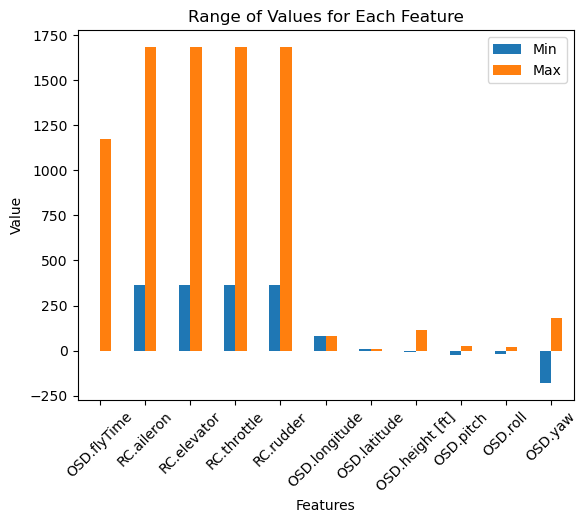

In [9]:
feature_ranges = df.describe().loc[['min', 'max']]

# Transpose the DataFrame for easier plotting
feature_ranges = feature_ranges.transpose()

print("Range of values for each feature:")
print(feature_ranges)
# Plot the range of values for each feature
plt.figure(figsize=(12, 6))
feature_ranges.plot(kind='bar', rot=45)
plt.title('Range of Values for Each Feature')
plt.xlabel('Features')
plt.ylabel('Value')
plt.legend(['Min', 'Max'])
plt.show()

In [10]:
# Calculate summary statistics for the dataset
summary_stats = df.describe()

# Display the summary statistics
print(summary_stats)

        OSD.flyTime    RC.aileron   RC.elevator   RC.throttle     RC.rudder  \
count  70998.000000  70998.000000  70998.000000  70998.000000  70998.000000   
mean     404.971513   1023.433984   1147.451970    991.788346   1028.267867   
std      279.644152     39.258057    230.800692    236.144737    230.265453   
min        0.000000    364.000000    364.000000    364.000000    364.000000   
25%      161.525000   1024.000000   1024.000000   1024.000000   1024.000000   
50%      370.300000   1024.000000   1024.000000   1024.000000   1024.000000   
75%      622.800000   1024.000000   1271.000000   1024.000000   1024.000000   
max     1176.300000   1684.000000   1684.000000   1684.000000   1684.000000   

       OSD.longitude  OSD.latitude  OSD.height [ft]     OSD.pitch  \
count   70998.000000  70998.000000     70998.000000  70998.000000   
mean       79.930664      6.992990         9.778288      0.766685   
std         0.082023      0.098089        17.662508      4.150309   
min        7

# Convert latitude and longitude into coordinates

#### UTM stands for Universal Transverse Mercator, which is a commonly used system for representing locations on the Earth's surface. It's a global map projection system that divides the Earth into a series of zones, each of which is represented by a transverse Mercator projection.In the UTM system, coordinates are expressed in meters relative to a specific origin within each zone. This makes it easy to perform calculations and measure distances accurately over relatively small areas. UTM coordinates consist of two components: easting (x-coordinate) and northing (y-coordinate), both measured in meters.The UTM system is widely used in cartography, land surveying, and geographic information systems (GIS) applications because of its accuracy, simplicity, and global coverage. It's particularly useful for mapping and navigation purposes, especially when detailed local measurements are needed.

In [11]:
# Define a function to convert latitude and longitude to UTM coordinates
def convert_to_cartesian(row):
    utm_x, utm_y, _, _ = utm.from_latlon(row['OSD.latitude'], row['OSD.longitude'])
    return pd.Series([utm_x, utm_y])  # Return a Series with two values

# Apply the conversion function to each row and create new columns for UTM coordinates
df[['utm_x', 'utm_y']] = df.apply(convert_to_cartesian, axis=1)

# Replace 'OSD.latitude' and 'OSD.longitude' values with 'utm_x' and 'utm_y' respectively
df['OSD.latitude'] = df['utm_x']
df['OSD.longitude'] = df['utm_y']

# Drop the 'utm_x' and 'utm_y' columns
df.drop(columns=['utm_x', 'utm_y'], inplace=True)

# Print the DataFrame
df.head()

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,0.0,1024,1024,1024,1024,828901.705097,428633.510463,0.0,5.7,2.5,113.9
1,0.1,1024,1024,1024,1024,828901.701554,428633.513768,0.0,5.7,2.5,114.0
2,0.2,1024,1024,1024,1024,828901.691256,428633.524786,0.0,5.7,2.5,114.0
3,0.3,1024,1024,1024,1024,828901.687161,428633.528090,0.0,5.7,2.5,114.0
4,0.4,1024,1024,1024,1024,828901.677998,428633.519250,0.0,5.7,2.5,114.1


# Data Cleaning

### Remove Null values

In [12]:
null_counts = df.isnull().sum(axis=1)
print(null_counts)

0        0
1        0
2        0
3        0
4        0
        ..
70993    0
70994    0
70995    0
70996    0
70997    0
Length: 70998, dtype: int64


## Identify Outliers

<Figure size 1500x1000 with 0 Axes>

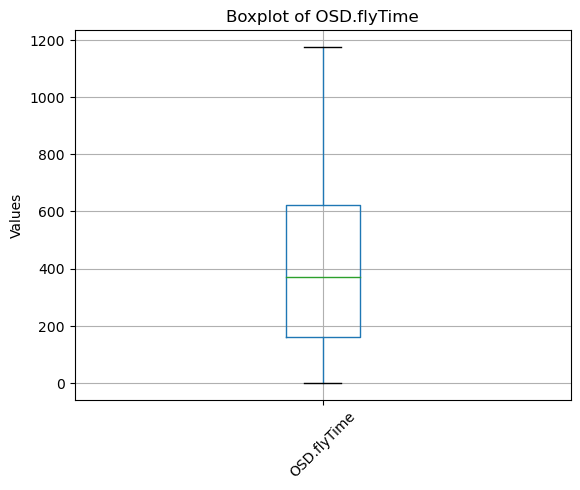

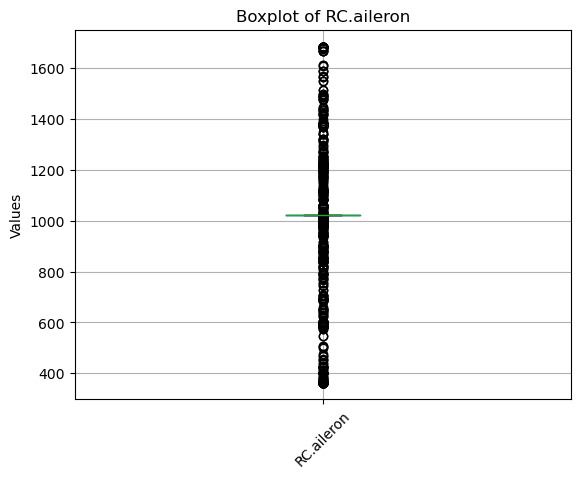

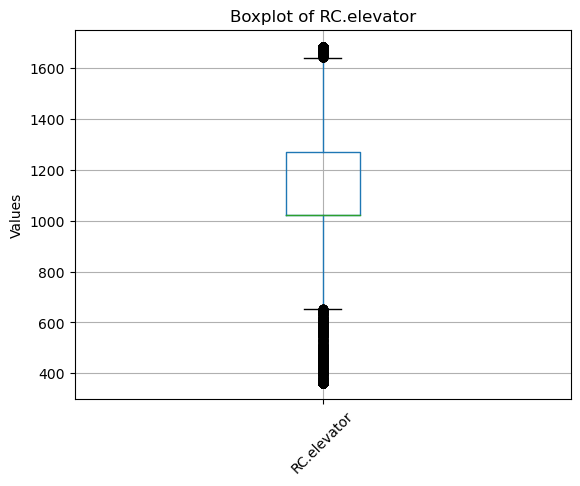

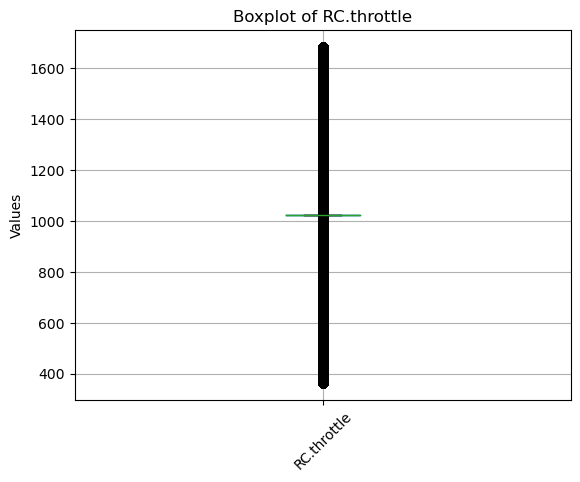

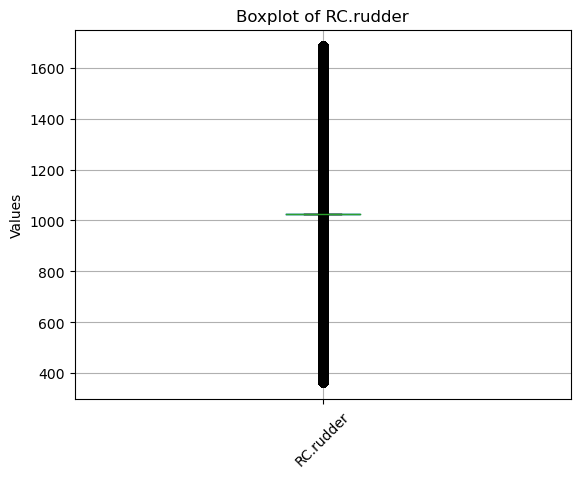

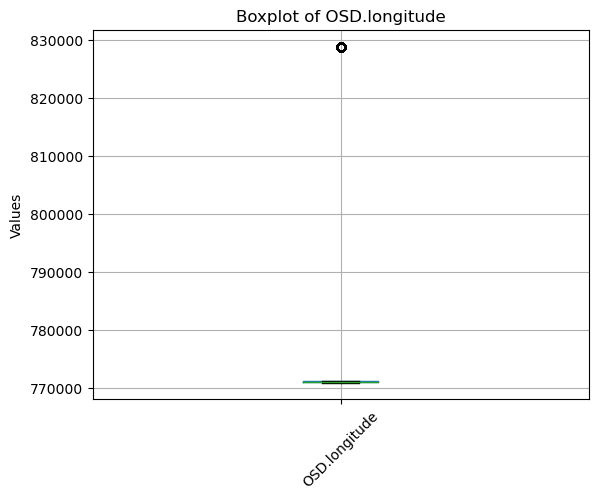

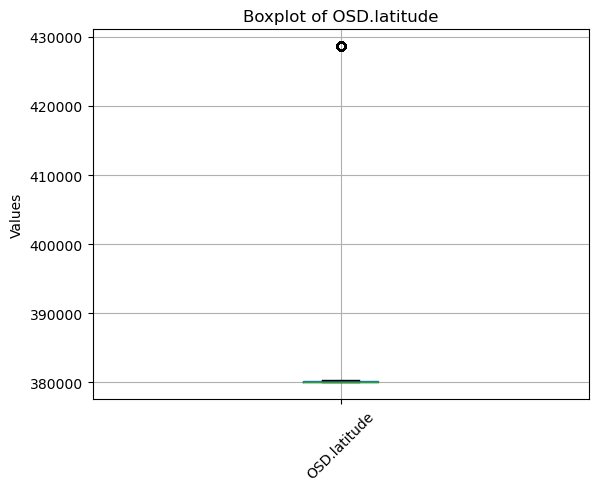

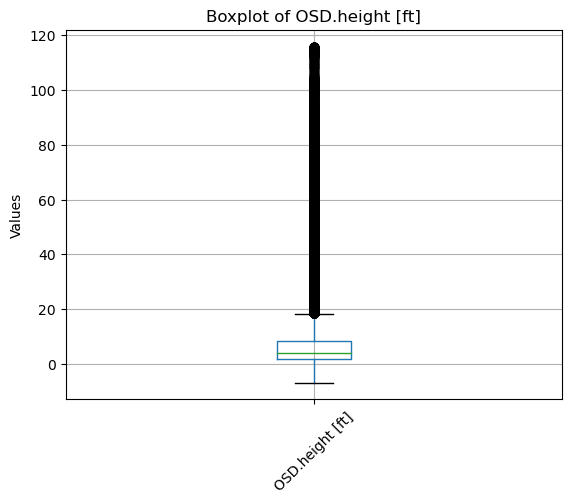

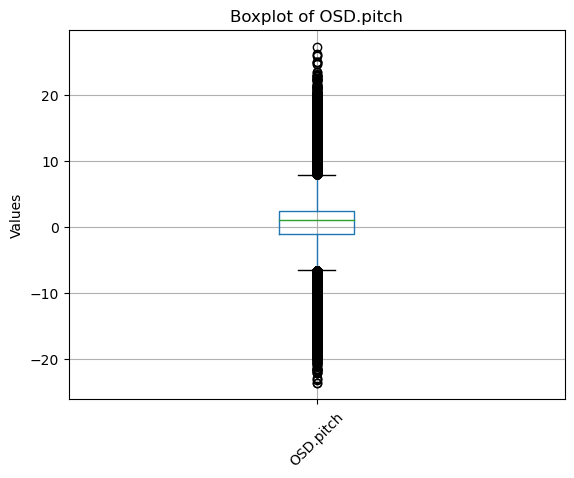

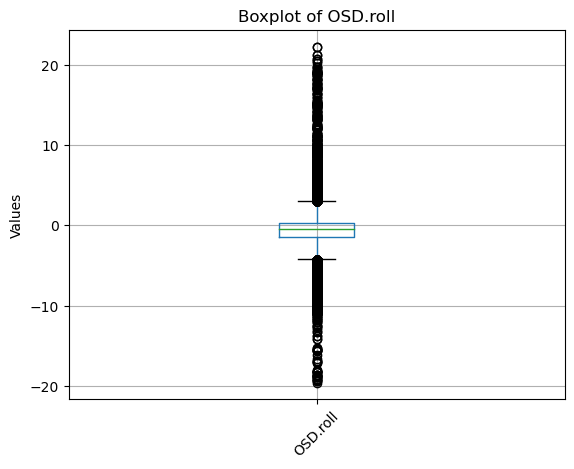

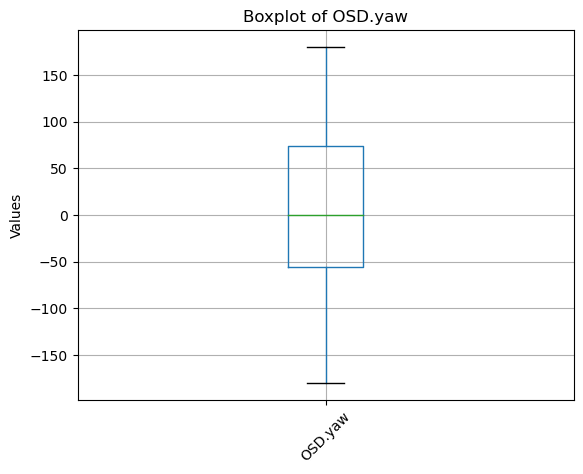

In [13]:
plt.figure(figsize=(15, 10))
for column in df.columns:
    plt.figure()
    df.boxplot(column=[column])
    plt.title(f'Boxplot of {column}')
    plt.ylabel('Values')
    plt.xticks(rotation=45)
    plt.show()

### Number of outliers for each feature

In [14]:
# Initialize an empty dictionary to store the number of outliers for each feature
outliers_count = {}

# Initialize total outliers count
total_outliers_count = 0

# Calculate the first quartile (Q1) and third quartile (Q3) for each feature
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate the interquartile range (IQR) for each feature
IQR = Q3 - Q1

# Define the lower and upper bounds for each feature
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Loop through each feature and count the number of outliers
for feature in df.columns:
    outliers_count[feature] = ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()
    total_outliers_count += ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()

# Display the number of outliers for each feature
print("Number of outliers for each feature:")
for feature, count in outliers_count.items():
    print(f"{feature}: {count}")
      
# Display the total number of outliers
print("Total number of outliers:", total_outliers_count)


Number of outliers for each feature:
OSD.flyTime: 0
RC.aileron: 658
RC.elevator: 5430
RC.throttle: 16543
RC.rudder: 16558
OSD.longitude: 2577
OSD.latitude: 2577
OSD.height [ft]: 8518
OSD.pitch: 5338
OSD.roll: 4978
OSD.yaw: 0
Total number of outliers: 63177


### Total outliers by rowise

#### In the first code snippet, outliers are counted for each feature individually, and then the total number of outliers is obtained by summing up these counts. This approach counts the outliers separately for each feature, resulting in a higher total count because it's possible for a data point to be an outlier in multiple features.In the second code snippet, outliers are detected based on whether any feature in a row exceeds the lower or upper bounds. This approach counts the total number of rows with at least one outlier, which may result in a lower total count because each row is counted only once, regardless of how many features in that row contain outliers.

In [15]:
# Calculate the first quartile (Q1) and third quartile (Q3)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = ((df < lower_bound) | (df > upper_bound)).any(axis=1)

# Print number of outliers
print("Number of outliers:", outliers.sum())


Number of outliers: 42023


# Ranking

In [16]:
# Assuming df is your DataFrame containing the selected features
# Apply rank transformation to each selected feature
for feature in df.columns:
    # Perform rank transformation
    df[feature] = df[feature].rank()
df.head()

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,6.5,35537.5,22826.5,35886.0,34939.5,70608.0,68608.0,3243.5,66040.5,68293.5,57771.5
1,18.5,35537.5,22826.5,35886.0,34939.5,70607.0,68611.0,3243.5,66040.5,68293.5,57779.0
2,30.5,35537.5,22826.5,35886.0,34939.5,70605.0,68618.0,3243.5,66040.5,68293.5,57779.0
3,42.5,35537.5,22826.5,35886.0,34939.5,70604.0,68622.0,3243.5,66040.5,68293.5,57779.0
4,54.5,35537.5,22826.5,35886.0,34939.5,70600.0,68613.0,3243.5,66040.5,68293.5,57787.5


In [17]:
# Initialize an empty dictionary to store the number of outliers for each feature
outliers_count = {}

# Initialize total outliers count
total_outliers_count = 0

# Calculate the first quartile (Q1) and third quartile (Q3) for each feature
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate the interquartile range (IQR) for each feature
IQR = Q3 - Q1

# Define the lower and upper bounds for each feature
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Loop through each feature and count the number of outliers
for feature in df.columns:
    outliers_count[feature] = ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()
    total_outliers_count += ((df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])).sum()

# Display the number of outliers for each feature
print("Number of outliers for each feature:")
for feature, count in outliers_count.items():
    print(f"{feature}: {count}")
      
# Display the total number of outliers
print("Total number of outliers:", total_outliers_count)


Number of outliers for each feature:
OSD.flyTime: 0
RC.aileron: 658
RC.elevator: 0
RC.throttle: 16543
RC.rudder: 16558
OSD.longitude: 0
OSD.latitude: 0
OSD.height [ft]: 0
OSD.pitch: 0
OSD.roll: 0
OSD.yaw: 0
Total number of outliers: 33759


# Normalize other features

In [18]:
# Instantiate the StandardScaler
scaler = StandardScaler()

# Define the columns to normalize
columns_to_normalize = ['OSD.flyTime','RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude','OSD.latitude',
                         'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Apply StandardScaler to the specified columns
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])
df.head()

,OSD.flyTime,RC.aileron,RC.elevator,RC.throttle,RC.rudder,OSD.longitude,OSD.latitude,OSD.height [ft],OSD.pitch,OSD.roll,OSD.yaw
0,-1.731758,0.011171,-0.693798,0.025468,-0.036873,1.712998,1.615415,-1.574614,1.49025,1.60052,1.086687
1,-1.731173,0.011171,-0.693798,0.025468,-0.036873,1.712949,1.615561,-1.574614,1.49025,1.60052,1.087053
2,-1.730587,0.011171,-0.693798,0.025468,-0.036873,1.712851,1.615903,-1.574614,1.49025,1.60052,1.087053
3,-1.730002,0.011171,-0.693798,0.025468,-0.036873,1.712803,1.616098,-1.574614,1.49025,1.60052,1.087053
4,-1.729416,0.011171,-0.693798,0.025468,-0.036873,1.712607,1.615659,-1.574614,1.49025,1.60052,1.087468


# Distribution of each features

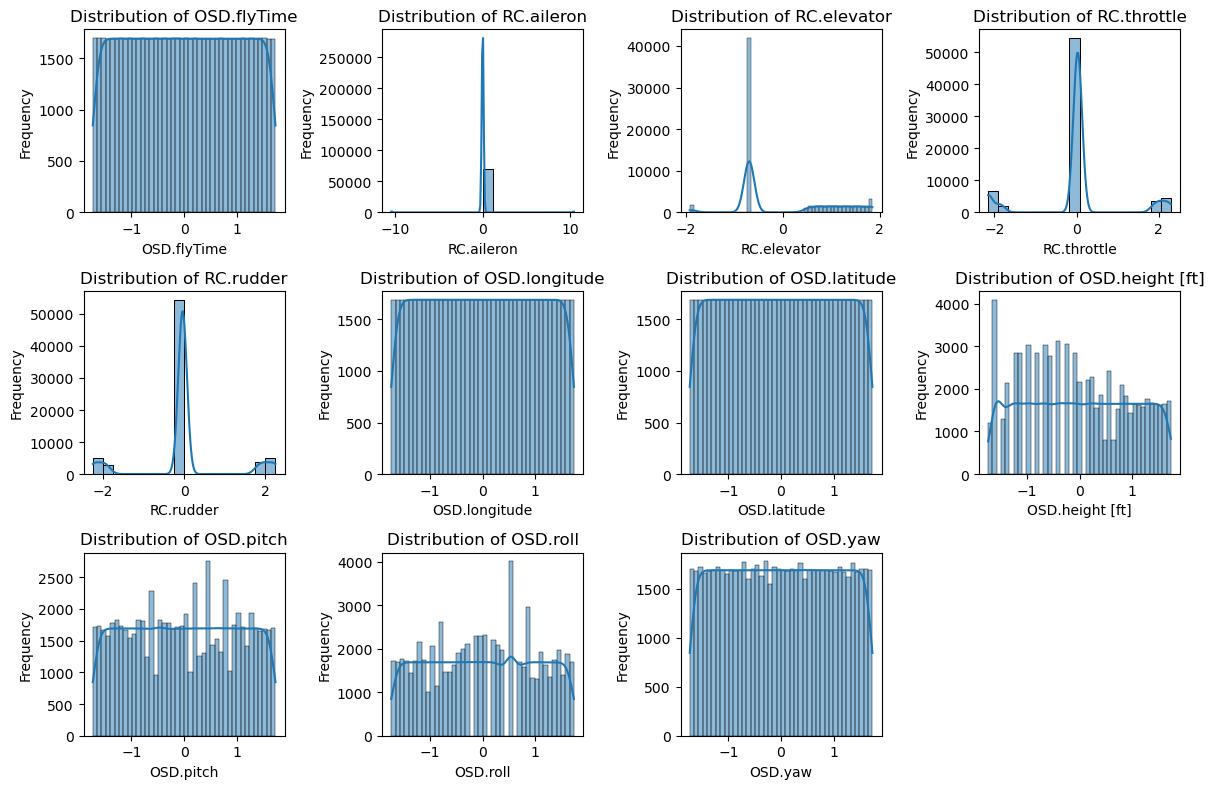

In [19]:
# Plot histograms for each feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(df.columns):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Correlation Matrix:
                 OSD.flyTime  RC.aileron  RC.elevator  RC.throttle  RC.rudder  \
OSD.flyTime         1.000000   -0.012774    -0.116657    -0.087558   0.005050   
RC.aileron         -0.012774    1.000000     0.026147     0.018422  -0.026556   
RC.elevator        -0.116657    0.026147     1.000000     0.176370   0.072695   
RC.throttle        -0.087558    0.018422     0.176370     1.000000   0.130093   
RC.rudder           0.005050   -0.026556     0.072695     0.130093   1.000000   
OSD.longitude      -0.130248    0.040329     0.066685     0.012918   0.065975   
OSD.latitude        0.079053    0.006545    -0.206237    -0.022443  -0.047343   
OSD.height [ft]    -0.065196    0.049829    -0.140833    -0.073549  -0.046543   
OSD.pitch           0.104585   -0.025283    -0.609519    -0.099686  -0.040973   
OSD.roll           -0.102164    0.059054     0.101063     0.059120   0.122856   
OSD.yaw            -0.061151    0.042406     0.030052     0.043348  -0.007200   

       

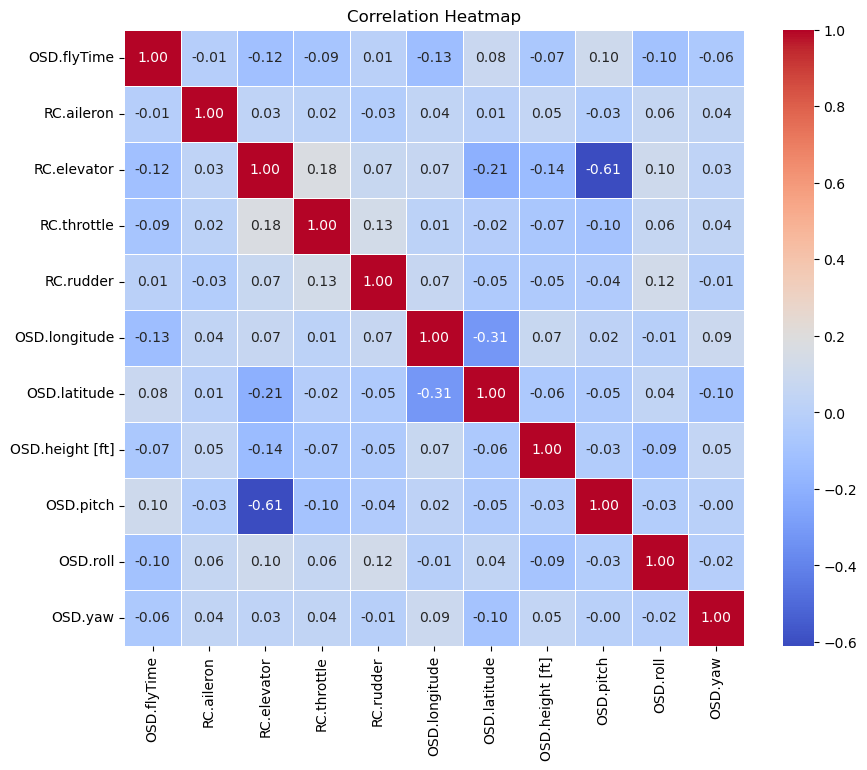

In [20]:
# Calculate correlation matrix
correlation_matrix = df.corr()

# Print correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

#### OSD.flyTime has a weak negative correlation with most variables.RC.aileron has a weak positive correlation with OSD.roll and a weak negative correlation with OSD.pitch.RC.elevator has a moderate positive correlation with OSD.height [ft] and a weak negative correlation with OSD.pitch.RC.throttle has no strong correlation with other variables.RC.rudder has a weak negative correlation with RC.aileron.OSD.longitude and OSD.latitude have a very strong positive correlation, which is expected since they represent coordinates on the same map.OSD.height [ft] has a weak negative correlation with RC.elevator.OSD.pitch has a moderate negative correlation with RC.elevator and a weak negative correlation with OSD.roll.OSD.roll has a weak positive correlation with RC.aileron and OSD.pitch.OSD.yaw has no strong correlation with other variables.

Fitting 3 folds for each of 10 candidates, totalling 30 fits
592/592 [==============================] - 1s 2ms/step
[CV] END batch_size=64, dropout_rate=0.5, epochs=50, layers=2, learning_rate=0.0001, neurons=32; total time= 1.4min
592/592 [==============================] - 1s 2ms/step
[CV] END batch_size=64, dropout_rate=0.5, epochs=50, layers=2, learning_rate=0.0001, neurons=32; total time= 1.3min
592/592 [==============================] - 1s 2ms/step
[CV] END batch_size=64, dropout_rate=0.5, epochs=50, layers=2, learning_rate=0.0001, neurons=32; total time= 1.2min
592/592 [==============================] - 1s 2ms/step
[CV] END batch_size=32, dropout_rate=0.3, epochs=100, layers=1, learning_rate=0.001, neurons=64; total time= 3.7min
592/592 [==============================] - 1s 2ms/step
[CV] END batch_size=32, dropout_rate=0.3, epochs=100, layers=1, learning_rate=0.001, neurons=64; total time= 3.9min
592/592 [==============================] - 1s 2ms/step
[CV] END batch_size=32, dropo

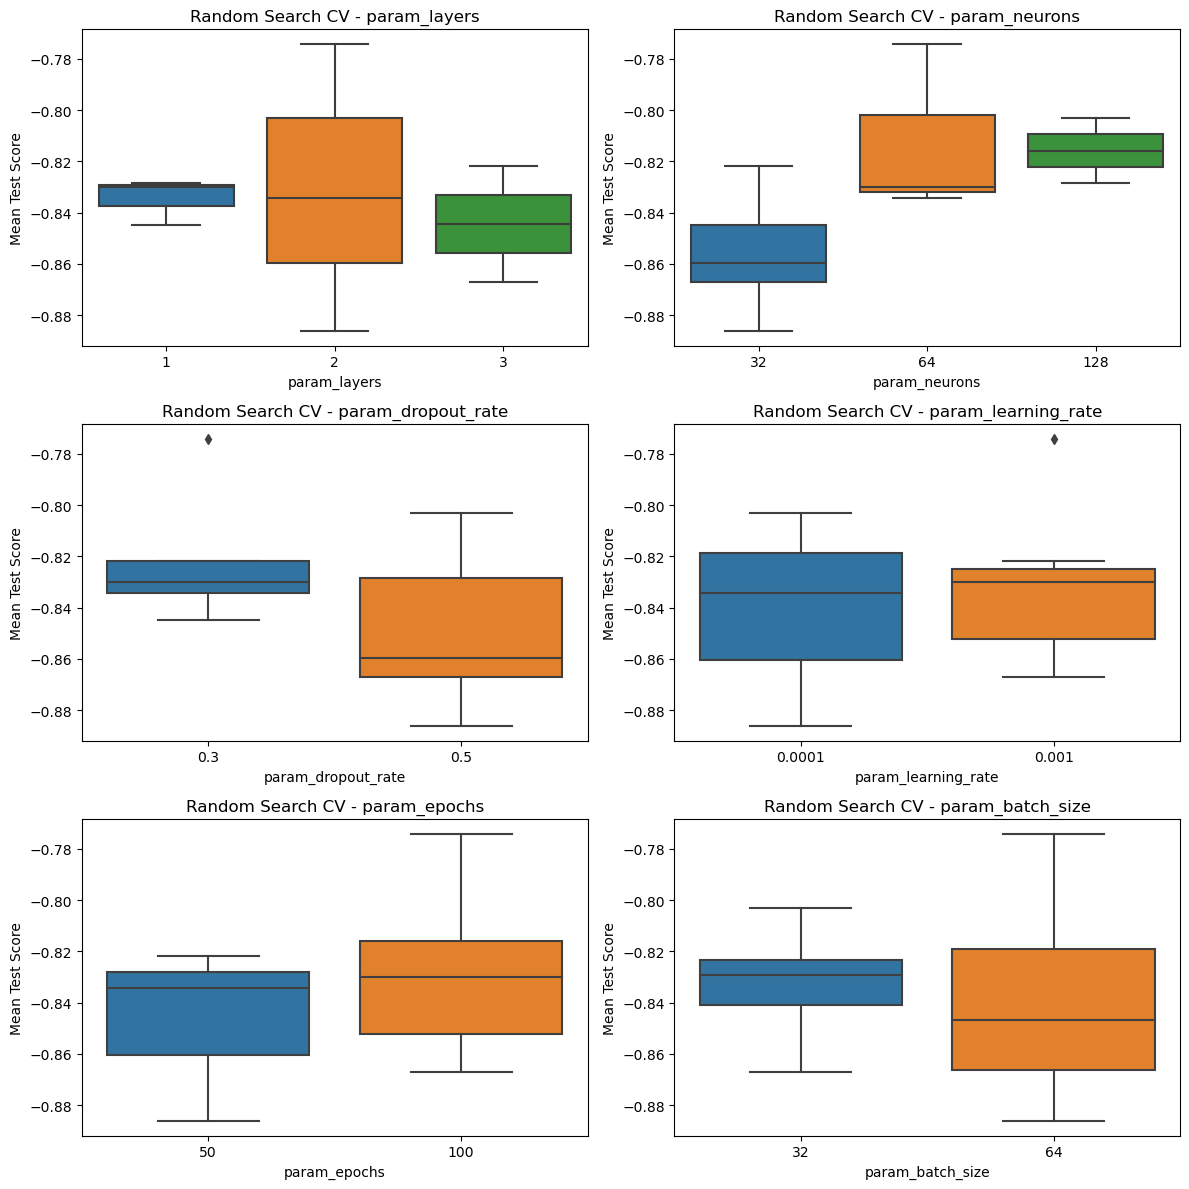

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from sklearn.base import BaseEstimator, RegressorMixin

# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Define a wrapper class for KerasRegressor
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, layers=1, neurons=64, dropout_rate=0.3, learning_rate=0.001, epochs=100, batch_size=32):
        self.layers = layers
        self.neurons = neurons
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = None

    def create_model(self):
        model = keras.Sequential()
        model.add(layers.Dense(self.neurons, activation='relu', input_shape=(X_train.shape[1],)))
        model.add(layers.Dropout(self.dropout_rate))
        for _ in range(self.layers - 1):
            model.add(layers.Dense(self.neurons, activation='relu'))
            model.add(layers.Dropout(self.dropout_rate))
        model.add(layers.Dense(len(output_targets)))
        optimizer = optimizers.Adam(learning_rate=self.learning_rate)
        model.compile(optimizer=optimizer, loss='mean_squared_error')
        return model

    def fit(self, X, y):
        self.model = self.create_model()
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return self

    def predict(self, X):
        return self.model.predict(X)

# Define hyperparameters to tune
param_dist = {
    'layers': [1, 2, 3], # number of hidden layers
    'neurons': [32, 64, 128], # number of neurons per layer
    'dropout_rate': [0.3, 0.5], # dropout rate
    'learning_rate': [0.001, 0.0001], # learning rate
    'epochs': [50, 100], # number of training epochs
    'batch_size': [32, 64] # batch size
}

# Create KerasRegressor wrapper
model = KerasRegressorWrapper()

# Perform random search
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=10, scoring='neg_mean_squared_error', cv=3, verbose=2, random_state=42, n_jobs=1)

random_search.fit(X_train, y_train)

# Print best parameters and best score
print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

# Extract results from random search
results = pd.DataFrame(random_search.cv_results_)

# Define hyperparameters to plot
hyperparameters = ['param_layers', 'param_neurons', 'param_dropout_rate', 'param_learning_rate',
                   'param_epochs', 'param_batch_size']

# Plot random search results
plt.figure(figsize=(12, 12))
for i, param in enumerate(hyperparameters):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=param, y='mean_test_score', data=results, ax=plt.gca())
    plt.title(f'Random Search CV - {param}')
    plt.xlabel(param)
    plt.ylabel('Mean Test Score')
plt.tight_layout()
plt.show()


In [25]:
# Selecting relevant features and target variables
input_features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder']
output_targets = ['OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

# Splitting the dataset into features and target variables
X = df[input_features]
y = df[output_targets]

# Handling missing values in input features using SimpleImputer
imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Build the model using best parameters
model = keras.Sequential()
model.add(layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.Dropout(0.3))
for _ in range(3 - 1):
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.3))
model.add(layers.Dense(len(output_targets)))

# Compile the model
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model
mse = model.evaluate(X_test, y_test, verbose=0)
print("Test Mean Squared Error:", mse)


Epoch 1/50
1420/1420 [==============================] - 6s 3ms/step - loss: 0.9495 - val_loss: 0.8985
Epoch 2/50
1420/1420 [==============================] - 4s 3ms/step - loss: 0.9135 - val_loss: 0.8819
Epoch 3/50
1420/1420 [==============================] - 4s 3ms/step - loss: 0.8996 - val_loss: 0.8682
Epoch 4/50
1420/1420 [==============================] - 4s 3ms/step - loss: 0.8914 - val_loss: 0.8594
Epoch 5/50
1420/1420 [==============================] - 4s 3ms/step - loss: 0.8862 - val_loss: 0.8536
Epoch 6/50
1420/1420 [==============================] - 4s 3ms/step - loss: 0.8810 - val_loss: 0.8510
Epoch 7/50
1420/1420 [==============================] - 4s 3ms/step - loss: 0.8780 - val_loss: 0.8448
Epoch 8/50
1420/1420 [==============================] - 4s 3ms/step - loss: 0.8738 - val_loss: 0.8415
Epoch 9/50
1420/1420 [==============================] - 4s 3ms/step - loss: 0.8731 - val_loss: 0.8396
Epoch 10/50
1420/1420 [==============================] - 4s 3ms/step - loss: 0.869

In [5]:
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)



# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.altitude [ft]'], c='blue', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()



NameError: name 'os' is not defined

31/31 [==============================] - 0s 2ms/step


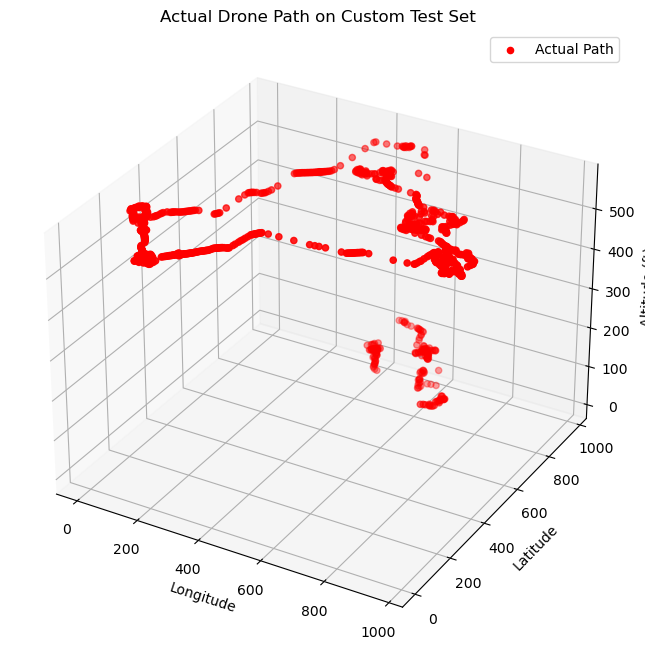

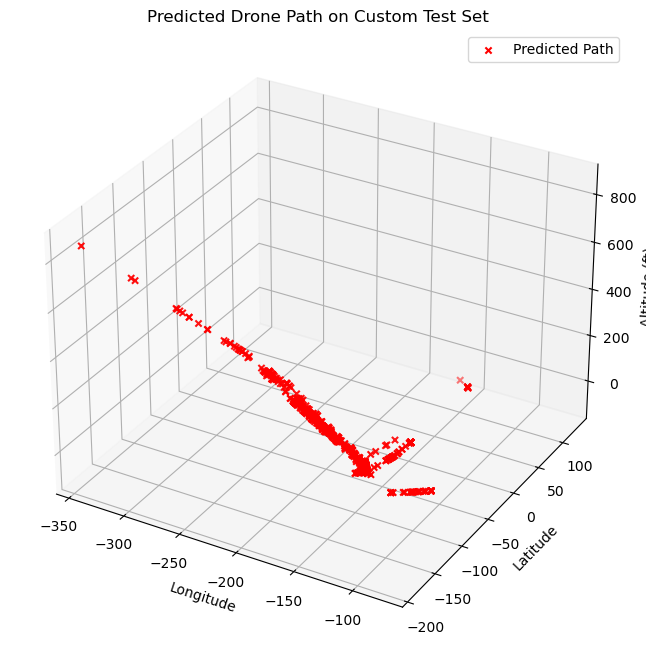

In [137]:
# Load the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Convert latitude and longitude to UTM coordinates
def convert_to_utm(row):
    utm_x, utm_y, _, _ = utm.from_latlon(row['OSD.latitude'], row['OSD.longitude'])
    return pd.Series([utm_x, utm_y])

df_test_custom[['OSD.latitude', 'OSD.longitude']] = df_test_custom.apply(convert_to_utm, axis=1)

# Handling missing values in input features using SimpleImputer
X_test_custom_imputed = imputer.transform(df_test_custom[input_features])

# Normalize the custom test data
X_test_custom_scaled = scaler.transform(X_test_custom_imputed)

# Apply rank transformation to each selected feature
for feature in df_test_custom.columns:
    df_test_custom[feature] = df_test_custom[feature].rank()

# Make predictions on the custom test set
y_pred_custom = model.predict(X_test_custom_scaled)

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.altitude [ft]'], c='red', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()

# Create a 3D plot for the predicted drone path on custom test set
fig_predicted_custom = plt.figure(figsize=(12, 8))
ax_predicted_custom = fig_predicted_custom.add_subplot(111, projection='3d')
ax_predicted_custom.scatter(y_pred_custom[:, 0], y_pred_custom[:, 1], y_pred_custom[:, 2], c='red', marker='x', label='Predicted Path')
ax_predicted_custom.set_xlabel('Longitude')
ax_predicted_custom.set_ylabel('Latitude')
ax_predicted_custom.set_zlabel('Altitude (ft)')
ax_predicted_custom.set_title('Predicted Drone Path on Custom Test Set')
ax_predicted_custom.legend()

# Show the actual and predicted path plots on the custom test set
plt.show()


Feature Importance:
       Feature  Importance
0  OSD.flyTime    0.772809
2  RC.elevator    0.227191
1   RC.aileron    0.000000
3  RC.throttle    0.000000
4    RC.rudder    0.000000


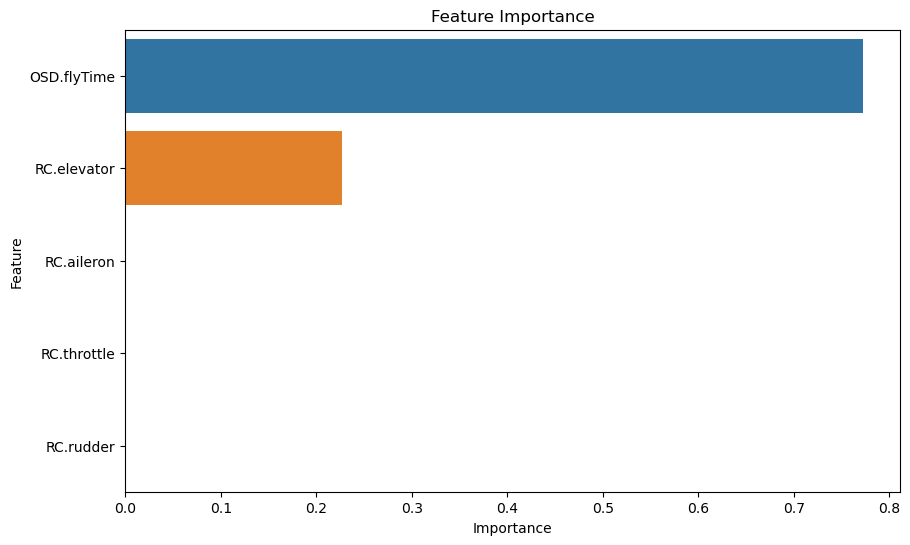

In [138]:
# Train a model with feature importances (example: RandomForestRegressor)
from sklearn.ensemble import RandomForestRegressor

# Define and fit the model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Get feature importances
feature_importances = model.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': input_features, 'Importance': feature_importances})

# Sort the DataFrame by feature importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Print the sorted DataFrame
print("Feature Importance:")
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()
